# 🌍 FIFA World Cup 2026 — Exploratory Data Analysis
### `01_eda.ipynb` · WC2026 Analytics & Prediction Pipeline

---

**Dataset:** `wc2026_ml_dataset.csv`  
**Purpose:** Comprehensive EDA before modelling — understand distributions, relationships, class balance, and derive feature-engineering hypotheses.

**Notebook flow:**
1. Setup & Data Loading  
2. Dataset Overview  
3. Target Variable Analysis  
4. Univariate Analysis (numeric + categorical)  
5. Bivariate Analysis (features vs target)  
6. Correlation & Multicollinearity  
7. Confederation-level Deep Dive  
8. Outlier Detection  
9. Key Findings & Feature Engineering Hypotheses  


## 1 · Setup & Imports

In [3]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

# Stats
from scipy import stats

# Display
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# ── Plot theme ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'font.family': 'sans-serif',
})

PALETTE_QUAL  = ['#2196F3', '#FF5722']   # Not qualified / Qualified
PALETTE_CONF  = sns.color_palette('tab10', 6)
CONF_ORDER    = ['UEFA', 'CAF', 'AFC', 'CONCACAF', 'CONMEBOL', 'OFC']

print("✅ Imports complete.")


✅ Imports complete.


## 2 · Data Loading & Overview

In [4]:
# ── Load ──────────────────────────────────────────────────────────────────
DATA_PATH = 'wc2026_ml_dataset.csv'   # adjust path if running locally
df = pd.read_csv(DATA_PATH)

print(f"Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head()


Shape  : 100 rows × 30 columns
Memory : 37.9 KB


,country,confederation,fifa_rank,fifa_rank_tier,fifa_points,elo_rating,squad_value_total_m,coach,coach_tenure_days,coach_success_rate,...,home_win_rate_last20,away_win_rate_last20,clean_sheet_rate,avg_opponent_elo_last10,xg_difference,unbeaten_streak,world_cup_appearances,world_cup_titles,continental_titles,qualified_for_wc2026
0,France,UEFA,1,1,1877.32,2052,1050.0,Didier Deschamps,4927,0.72,...,0.78,0.55,0.4,1830,0.82,12,16,2,2,1
1,Spain,UEFA,2,1,1876.40,2041,950.0,Luis de la Fuente,847,0.78,...,0.85,0.62,0.5,1850,1.15,18,16,1,4,1
2,Argentina,CONMEBOL,3,1,1874.81,2038,950.0,Lionel Scaloni,2374,0.75,...,0.84,0.58,0.5,1820,0.94,18,19,3,15,1
3,England,UEFA,4,1,1825.97,1998,1150.0,Thomas Tuchel,253,0.68,...,0.78,0.55,0.4,1800,0.71,9,17,1,3,1
4,Portugal,UEFA,5,1,1763.83,1942,780.0,Roberto Martinez,1005,0.68,...,0.78,0.58,0.4,1790,0.88,11,9,0,2,1


In [5]:
# ── Column catalogue ──────────────────────────────────────────────────────
col_info = pd.DataFrame({
    'dtype'       : df.dtypes.astype(str),
    'non_null'    : df.notnull().sum(),
    'null_count'  : df.isnull().sum(),
    'nunique'     : df.nunique(),
    'sample_vals' : [df[c].dropna().head(3).tolist() for c in df.columns]
})

# Annotate with domain group
groups = {
    'Identity'       : ['country', 'confederation'],
    'Ranking'        : ['fifa_rank', 'fifa_rank_tier', 'fifa_points', 'elo_rating'],
    'Squad Quality'  : ['squad_value_total_m', 'players_top5_leagues', 'top_scorer_goals',
                        'squad_depth_score', 'avg_player_age'],
    'Coach'          : ['coach', 'coach_tenure_days', 'coach_success_rate'],
    'Form / Results' : ['avg_goals_scored_last10', 'avg_goals_conceded_last10',
                        'win_rate_last5', 'win_rate_last10', 'win_rate_last20',
                        'draw_rate_last10', 'home_win_rate_last20', 'away_win_rate_last20',
                        'clean_sheet_rate', 'avg_opponent_elo_last10', 'xg_difference',
                        'unbeaten_streak'],
    'History'        : ['world_cup_appearances', 'world_cup_titles', 'continental_titles'],
    'Target'         : ['qualified_for_wc2026'],
}
rev = {col: grp for grp, cols in groups.items() for col in cols}
col_info['group'] = col_info.index.map(rev)
col_info.sort_values('group')


,dtype,non_null,null_count,nunique,sample_vals,group
coach_tenure_days,int64,100,0,86,"[4927, 847, 2374]",Coach
coach_success_rate,float64,100,0,35,"[0.72, 0.78, 0.75]",Coach
coach,object,100,0,98,"[Didier Deschamps, Luis de la Fuente, Lionel S...",Coach
avg_goals_conceded_last10,float64,100,0,71,"[0.9, 0.8, 0.7]",Form / Results
win_rate_last20,float64,100,0,45,"[0.65, 0.72, 0.7]",Form / Results
draw_rate_last10,float64,100,0,25,"[0.1, 0.1, 0.1]",Form / Results
home_win_rate_last20,float64,100,0,44,"[0.78, 0.85, 0.84]",Form / Results
away_win_rate_last20,float64,100,0,46,"[0.55, 0.62, 0.58]",Form / Results
avg_goals_scored_last10,float64,100,0,66,"[2.1, 2.3, 2.0]",Form / Results
clean_sheet_rate,float64,100,0,35,"[0.4, 0.5, 0.5]",Form / Results


In [6]:
# ── Dtypes summary ────────────────────────────────────────────────────────
print("Data types:")
print(df.dtypes.value_counts())

print("\nMissing values: NONE" if df.isnull().sum().sum() == 0
      else f"\n⚠️  {df.isnull().sum().sum()} missing cells detected")


Data types:
float64    15
int64      12
object      3
Name: count, dtype: int64

Missing values: NONE


In [7]:
# ── Full descriptive statistics ────────────────────────────────────────────
desc = df.describe().T
desc['cv%'] = (desc['std'] / desc['mean'] * 100).round(1)   # coefficient of variation
desc.style.background_gradient(axis=0, cmap='Blues', subset=['mean', 'std', 'cv%'])


,count,mean,std,min,25%,50%,75%,max,cv%
fifa_rank,100.000000,49.920000,33.252532,1.000000,25.750000,46.500000,71.250000,179.000000,66.600000
fifa_rank_tier,100.000000,2.800000,1.082459,1.000000,2.000000,3.000000,4.000000,5.000000,38.700000
fifa_points,100.000000,1567.601700,243.566628,588.590000,1426.942500,1612.250000,1756.370000,1910.860000,15.500000
elo_rating,100.000000,1772.080000,228.417909,840.000000,1636.500000,1824.500000,1939.250000,2060.000000,12.900000
squad_value_total_m,100.000000,829.292000,232.441990,82.900000,699.925000,868.400000,997.000000,1250.000000,28.000000
coach_tenure_days,100.000000,817.080000,662.790499,60.000000,433.750000,672.500000,921.000000,4927.000000,81.100000
coach_success_rate,100.000000,0.555700,0.092543,0.290000,0.490000,0.550000,0.612500,0.780000,16.700000
avg_player_age,100.000000,26.334000,0.919181,23.800000,25.900000,26.400000,26.800000,28.700000,3.500000
players_top5_leagues,100.000000,18.740000,3.968614,5.000000,16.000000,19.500000,21.000000,26.000000,21.200000
top_scorer_goals,100.000000,14.160000,3.594946,4.000000,12.000000,14.000000,17.000000,20.000000,25.400000


## 3 · Target Variable — `qualified_for_wc2026`

The target is **binary**: 1 = qualified for the 2026 World Cup, 0 = did not qualify.  
Understanding class balance is critical before modelling — a heavily skewed target can lead to a naïve classifier that predicts the majority class.


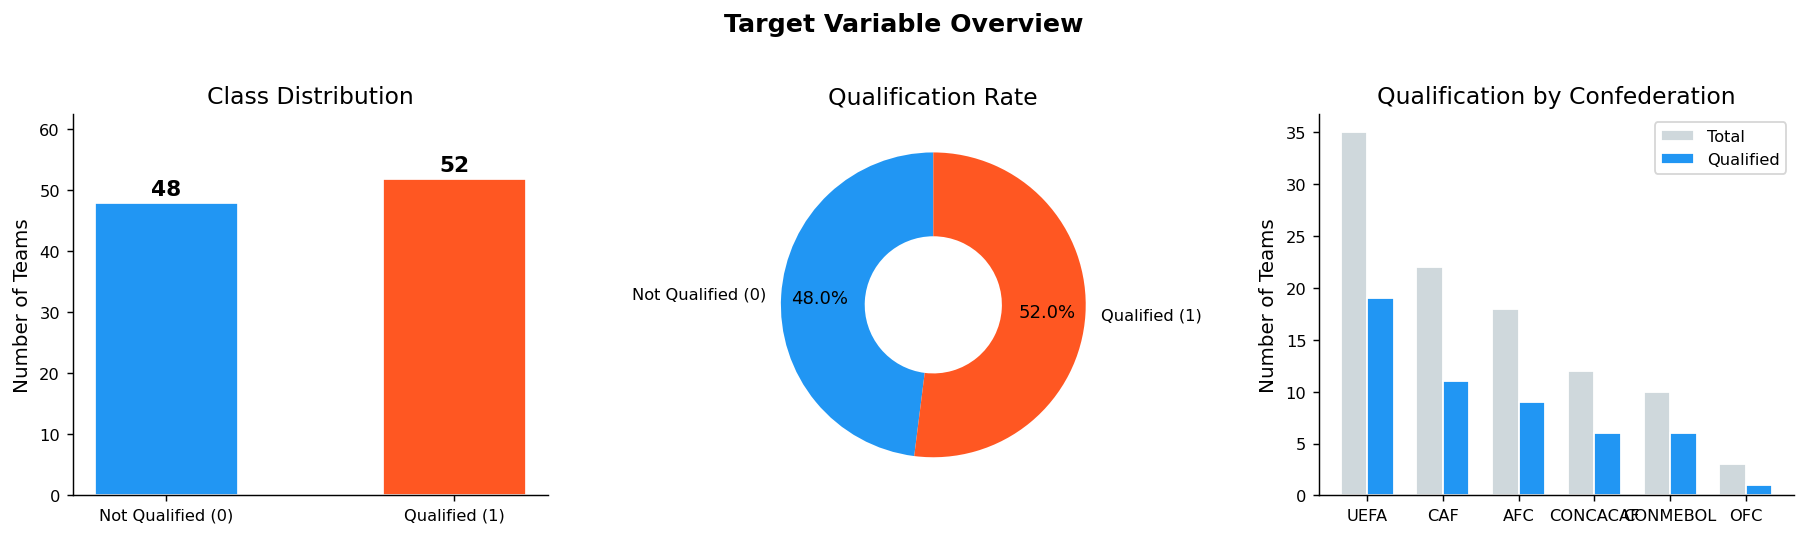


Total teams       : 100
Qualified (1)     : 52  (52.0%)
Not qualified (0) : 48  (48.0%)
Class imbalance   : MILD — manageable without resampling


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# — A. Count bar chart ———————————————————————————————————————————————————
counts = df['qualified_for_wc2026'].value_counts().sort_index()
labels = ['Not Qualified (0)', 'Qualified (1)']

bars = axes[0].bar(labels, counts.values, color=PALETTE_QUAL, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Teams')
axes[0].set_ylim(0, counts.max() * 1.2)

# — B. Pie / donut ————————————————————————————————————————————————————————
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=PALETTE_QUAL,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55))
axes[1].set_title('Qualification Rate')

# — C. By confederation ———————————————————————————————————————————————————
conf_qual = (df.groupby('confederation')['qualified_for_wc2026']
               .agg(['sum', 'count'])
               .rename(columns={'sum': 'qualified', 'count': 'total'})
               .assign(rate=lambda x: x['qualified'] / x['total'] * 100)
               .reindex(CONF_ORDER))

x = np.arange(len(conf_qual))
w = 0.35
axes[2].bar(x - w/2, conf_qual['total'],   width=w, label='Total',     color='#CFD8DC', edgecolor='white')
axes[2].bar(x + w/2, conf_qual['qualified'], width=w, label='Qualified', color='#2196F3', edgecolor='white')
axes[2].set_xticks(x); axes[2].set_xticklabels(CONF_ORDER)
axes[2].set_title('Qualification by Confederation')
axes[2].set_ylabel('Number of Teams')
axes[2].legend()

plt.suptitle('Target Variable Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nTotal teams       : {len(df)}")
print(f"Qualified (1)     : {counts[1]}  ({counts[1]/len(df)*100:.1f}%)")
print(f"Not qualified (0) : {counts[0]}  ({counts[0]/len(df)*100:.1f}%)")
print(f"Class imbalance   : {'MILD — manageable without resampling' if 0.4 < counts[1]/len(df) < 0.6 else '⚠️  Imbalanced'}")


## 4 · Univariate Analysis

### 4.1 Numeric features — distribution overview

We look at the shape of each numeric feature.  
Key questions: Is it normally distributed? Skewed? Bimodal? Are there extreme outliers?


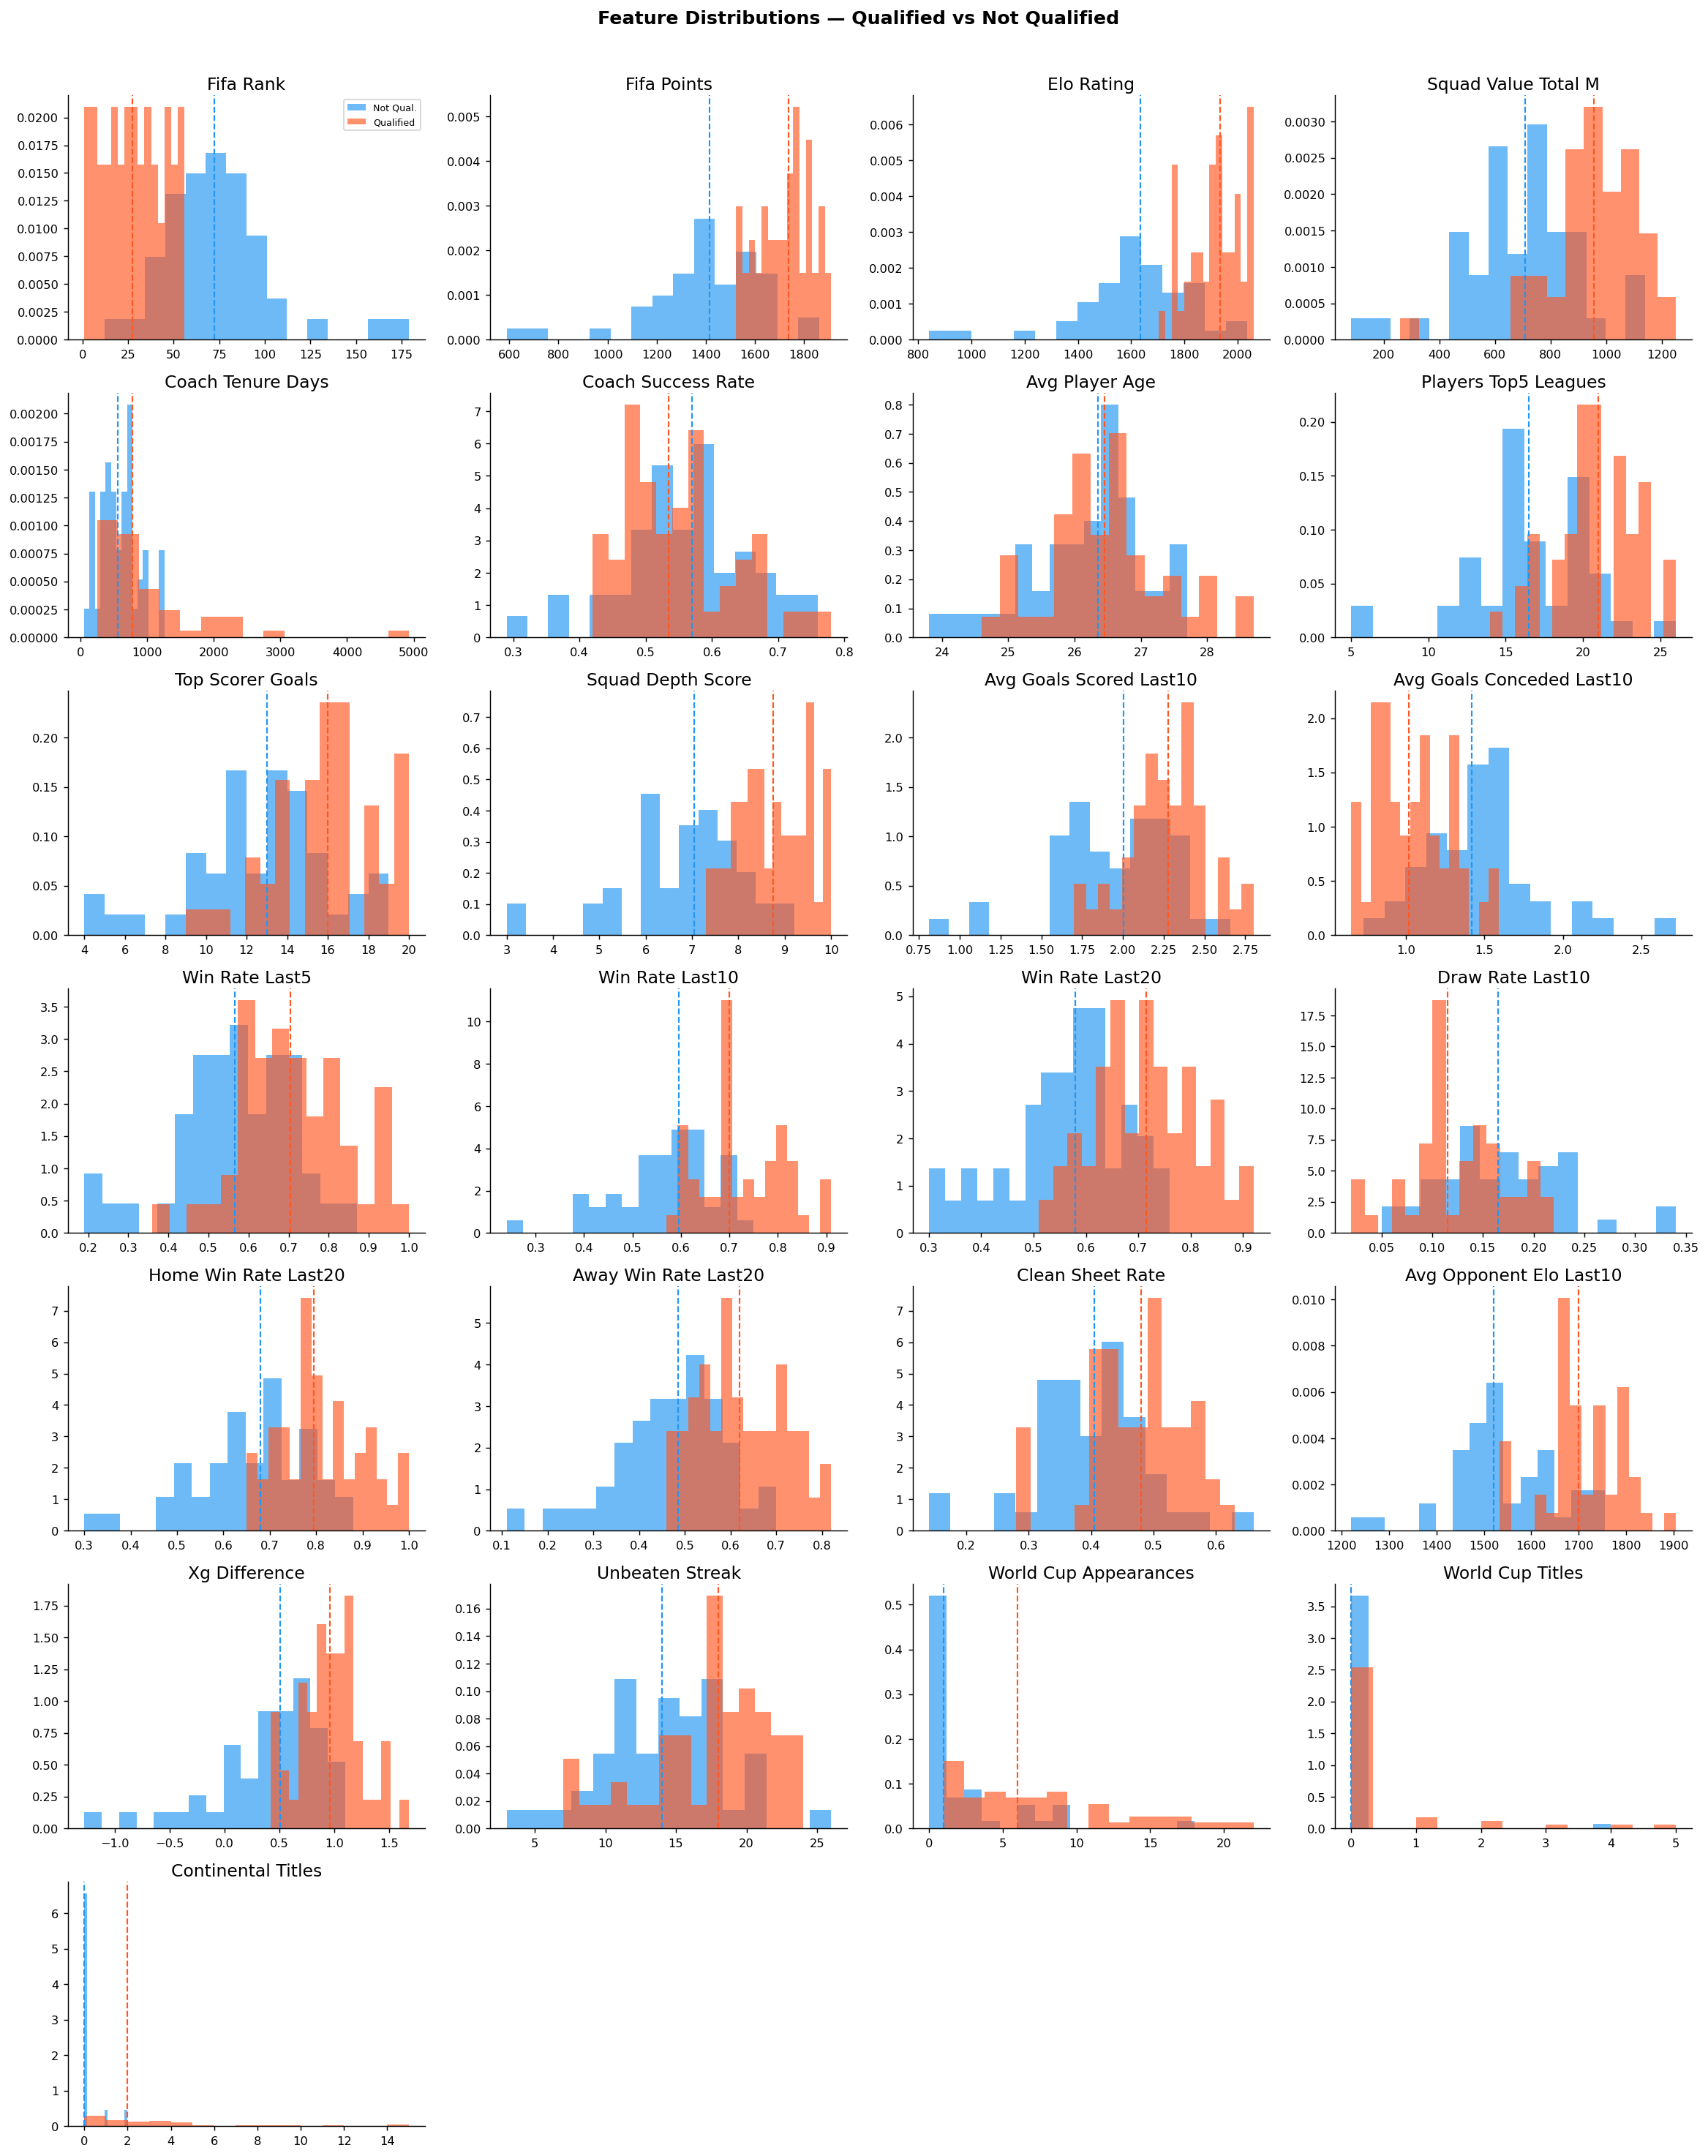

Dashed lines = medians. Orange = Qualified, Blue = Not Qualified.


In [9]:
NUMERIC_COLS = [c for c in df.select_dtypes(include='number').columns
                if c not in ['qualified_for_wc2026', 'fifa_rank_tier']]

n_cols = 4
n_rows = int(np.ceil(len(NUMERIC_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    q_data = df.loc[df['qualified_for_wc2026'] == 1, col]
    nq_data = df.loc[df['qualified_for_wc2026'] == 0, col]

    ax.hist(nq_data, bins=15, color=PALETTE_QUAL[0], alpha=0.65, label='Not Qual.', density=True)
    ax.hist(q_data,  bins=15, color=PALETTE_QUAL[1], alpha=0.65, label='Qualified', density=True)

    ax.axvline(q_data.median(),  color=PALETTE_QUAL[1], linestyle='--', linewidth=1.2)
    ax.axvline(nq_data.median(), color=PALETTE_QUAL[0], linestyle='--', linewidth=1.2)

    ax.set_title(col.replace('_', ' ').title(), pad=4)
    ax.set_xlabel('')
    if i == 0: ax.legend(fontsize=7)

# hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions — Qualified vs Not Qualified', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("Dashed lines = medians. Orange = Qualified, Blue = Not Qualified.")


### 4.2 Categorical features

Confederation distribution and FIFA rank tier.


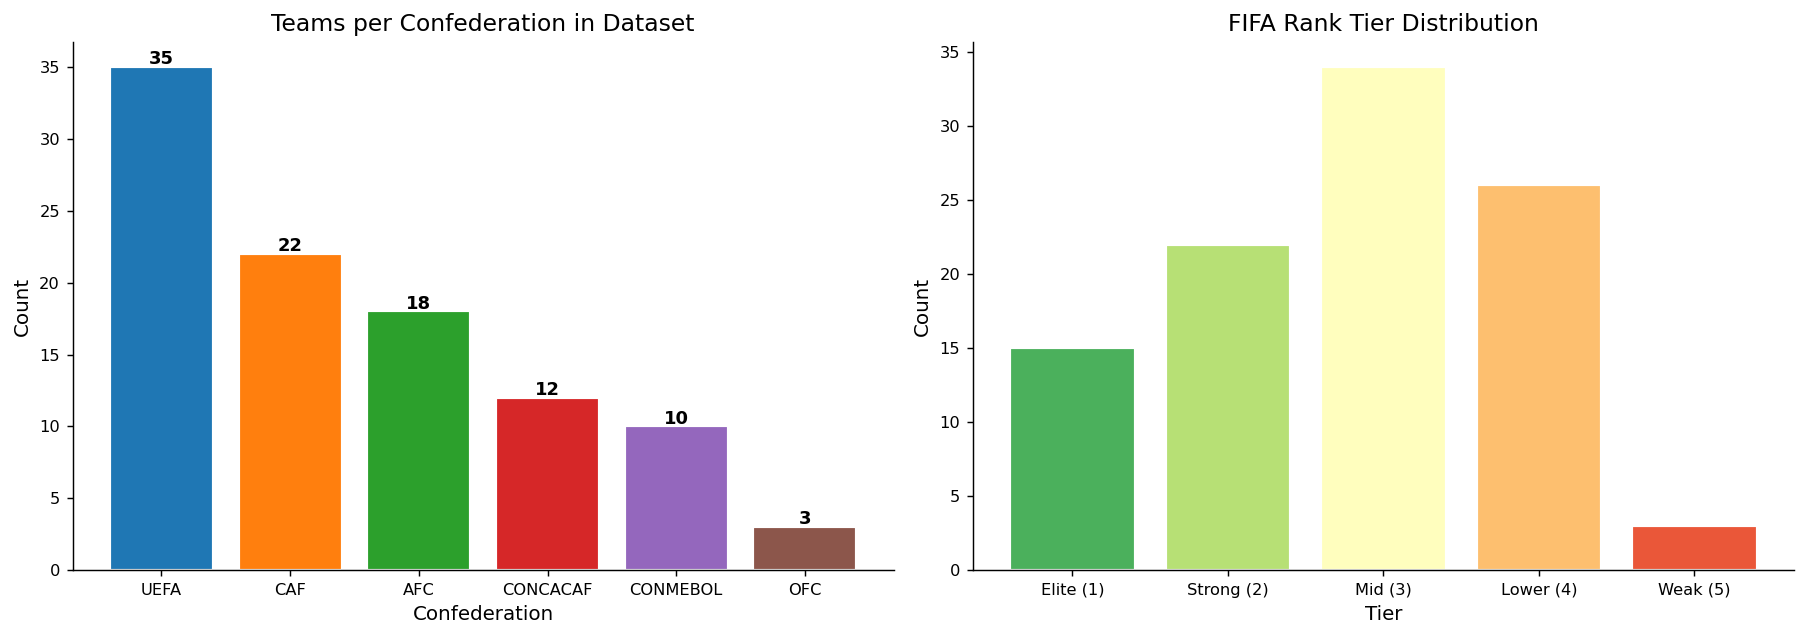

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Confederation ————————————————————————————————————————————————————————
conf_counts = df['confederation'].value_counts().reindex(CONF_ORDER)
bars = axes[0].bar(conf_counts.index, conf_counts.values,
                   color=PALETTE_CONF, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, conf_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(v), ha='center', fontweight='bold')
axes[0].set_title('Teams per Confederation in Dataset')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Confederation')

# — FIFA rank tier ————————————————————————————————————————————————————————
tier_label = {1: 'Elite (1)', 2: 'Strong (2)', 3: 'Mid (3)', 4: 'Lower (4)', 5: 'Weak (5)'}
tier_counts = df['fifa_rank_tier'].value_counts().sort_index()
axes[1].bar([tier_label[t] for t in tier_counts.index], tier_counts.values,
            color=sns.color_palette('RdYlGn_r', 5), edgecolor='white', linewidth=1.2)
axes[1].set_title('FIFA Rank Tier Distribution')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Tier')

plt.tight_layout()
plt.show()


## 5 · Bivariate Analysis — Features vs Target

Box plots reveal whether the median and spread differ meaningfully between qualified and non-qualified teams for each feature.  
We also run a **Mann-Whitney U test** (non-parametric) for statistical significance.


In [11]:
from scipy.stats import mannwhitneyu

results = []
for col in NUMERIC_COLS:
    grp1 = df.loc[df['qualified_for_wc2026'] == 1, col]
    grp0 = df.loc[df['qualified_for_wc2026'] == 0, col]
    stat, p = mannwhitneyu(grp1, grp0, alternative='two-sided')
    results.append({
        'feature'        : col,
        'median_qual'    : grp1.median(),
        'median_not_qual': grp0.median(),
        'delta_pct'      : (grp1.median() - grp0.median()) / (grp0.median() + 1e-9) * 100,
        'mw_p_value'     : p,
        'significant'    : '✅' if p < 0.05 else '❌'
    })

mw_df = pd.DataFrame(results).sort_values('mw_p_value')
mw_df.style.format({'median_qual': '{:.3f}', 'median_not_qual': '{:.3f}',
                    'delta_pct': '{:.1f}%', 'mw_p_value': '{:.4f}'})           .background_gradient(subset=['mw_p_value'], cmap='RdYlGn_r')


,feature,median_qual,median_not_qual,delta_pct,mw_p_value,significant
0,fifa_rank,27.500,72.500,-62.1%,0.0000,✅
2,elo_rating,1934.000,1634.000,18.4%,0.0000,✅
1,fifa_points,1738.355,1413.955,22.9%,0.0000,✅
9,squad_depth_score,8.750,7.050,24.1%,0.0000,✅
19,avg_opponent_elo_last10,1700.500,1520.500,11.8%,0.0000,✅
13,win_rate_last10,0.700,0.595,17.6%,0.0000,✅
3,squad_value_total_m,955.900,709.650,34.7%,0.0000,✅
20,xg_difference,0.960,0.505,90.1%,0.0000,✅
11,avg_goals_conceded_last10,1.020,1.420,-28.2%,0.0000,✅
24,continental_titles,2.000,0.000,200000000000.0%,0.0000,✅


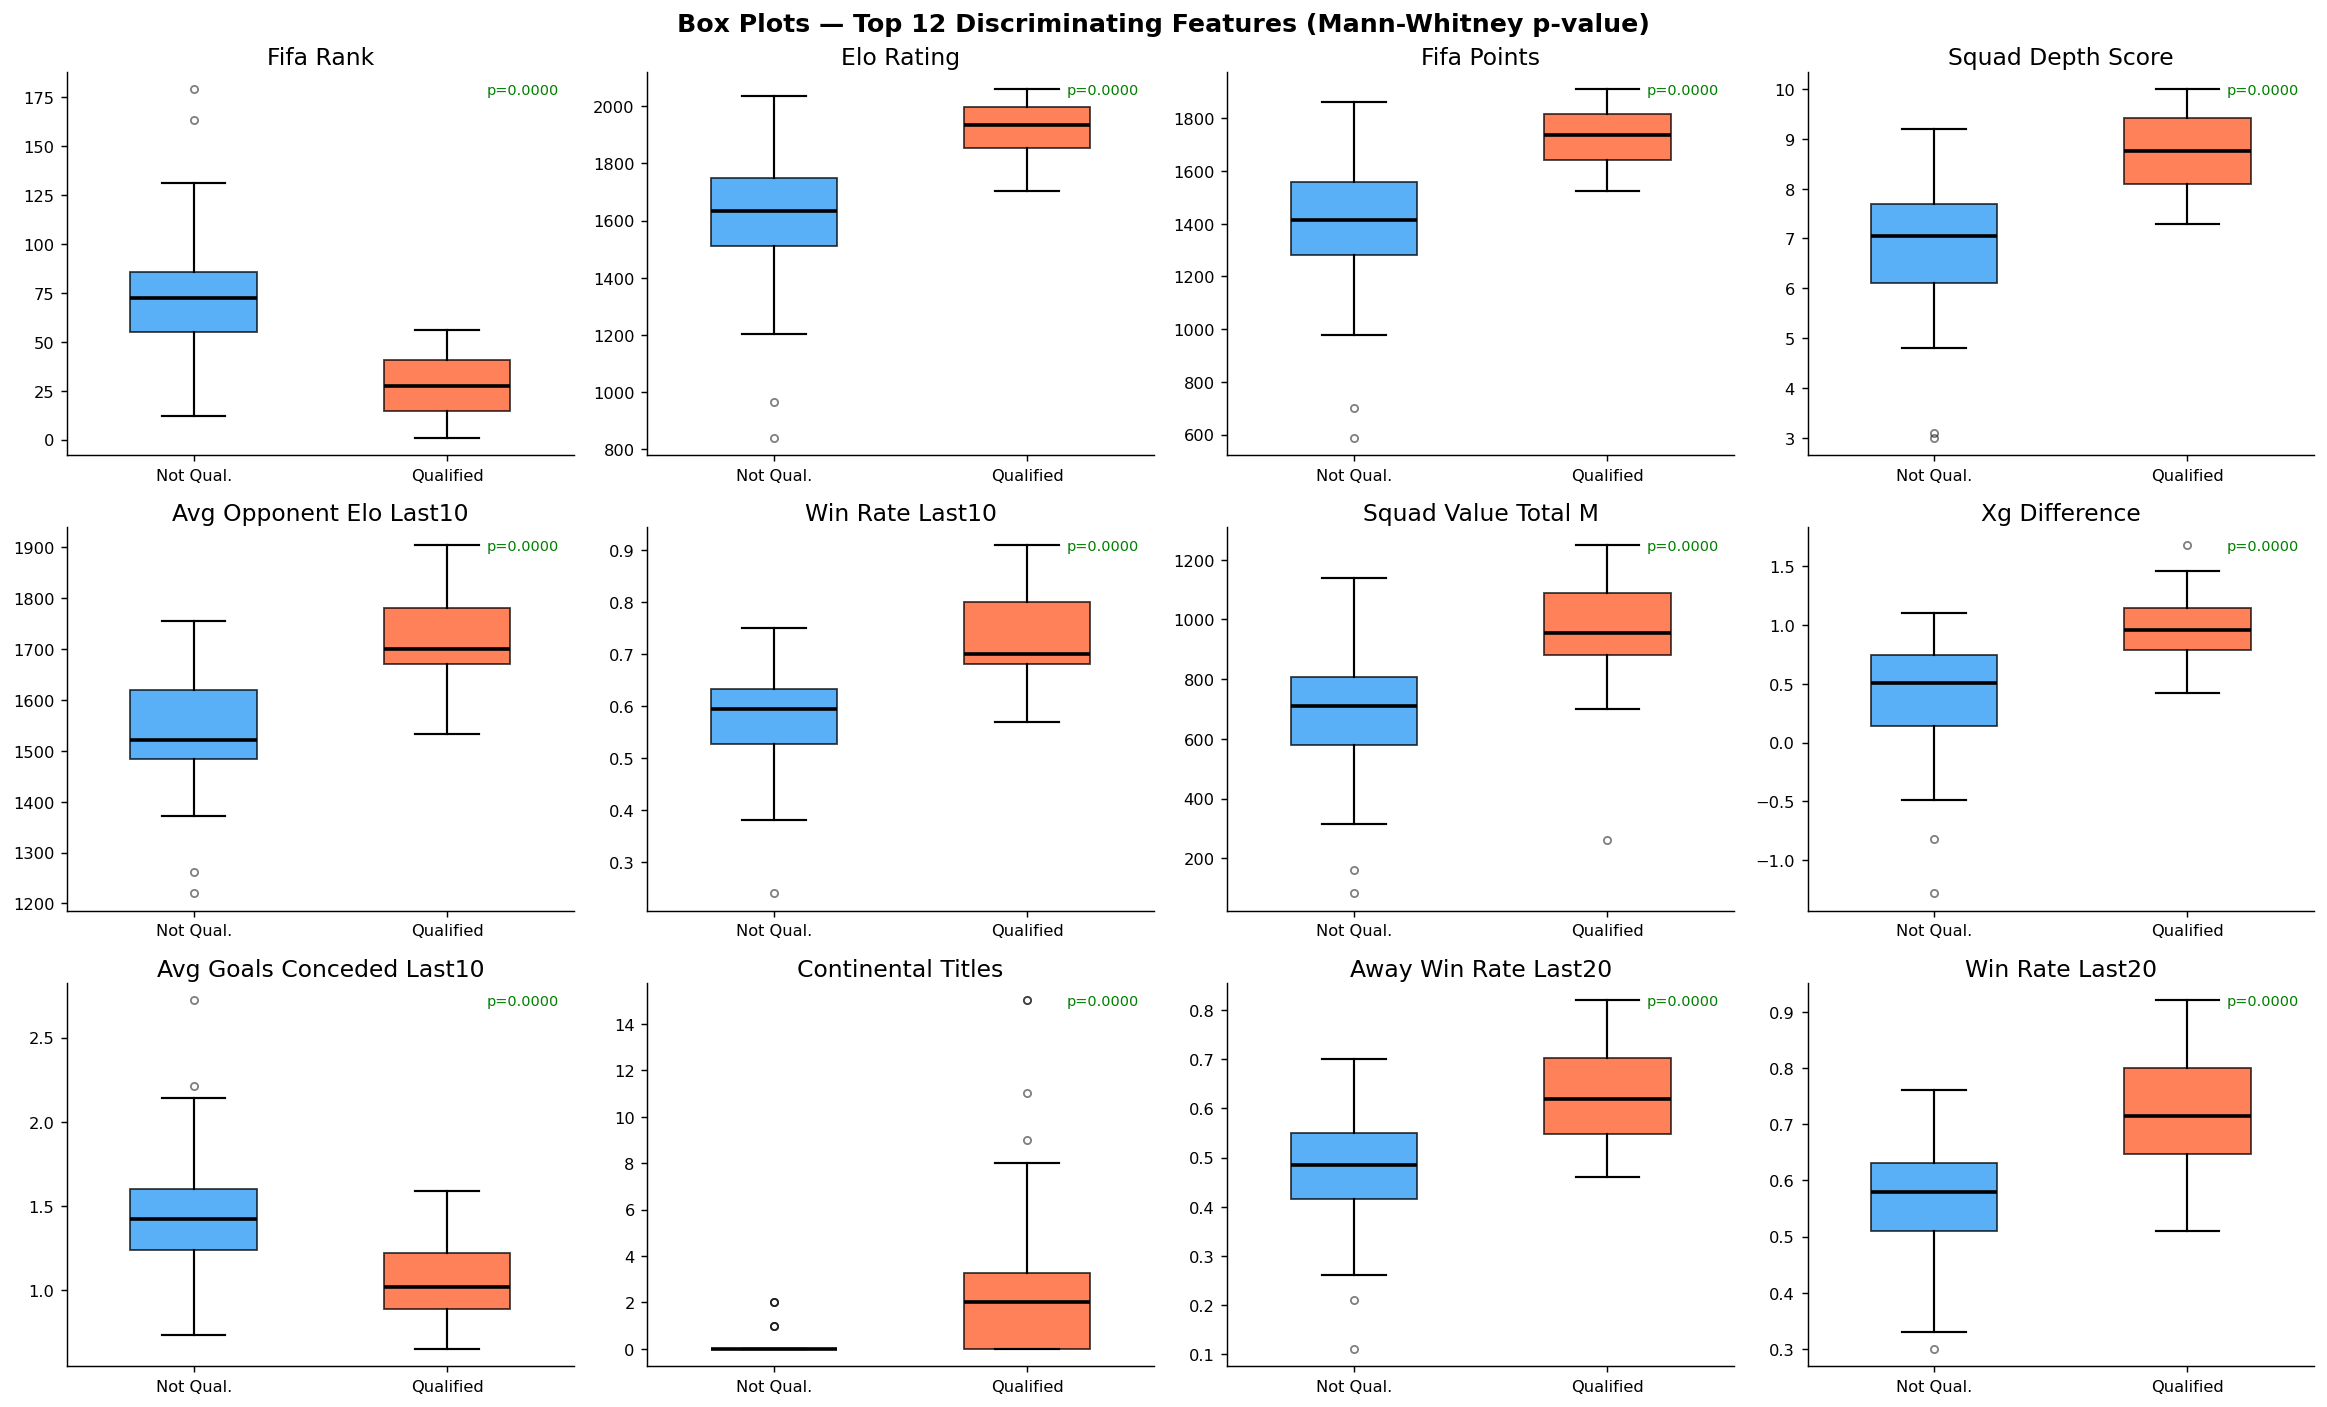

In [12]:
# ── Box plots for top 12 most significant features ────────────────────────
top12 = mw_df.head(12)['feature'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(top12):
    ax = axes[i]
    data_plot = [df.loc[df['qualified_for_wc2026'] == 0, col],
                 df.loc[df['qualified_for_wc2026'] == 1, col]]
    bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))
    for patch, color in zip(bp['boxes'], PALETTE_QUAL):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticklabels(['Not Qual.', 'Qualified'])
    ax.set_title(col.replace('_', ' ').title(), pad=4)
    # annotate p-value
    pval = mw_df.loc[mw_df['feature'] == col, 'mw_p_value'].values[0]
    ax.text(0.97, 0.97, f'p={pval:.4f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            color='green' if pval < 0.05 else 'red')

plt.suptitle('Box Plots — Top 12 Discriminating Features (Mann-Whitney p-value)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.1 Scatter plots — key pairwise relationships


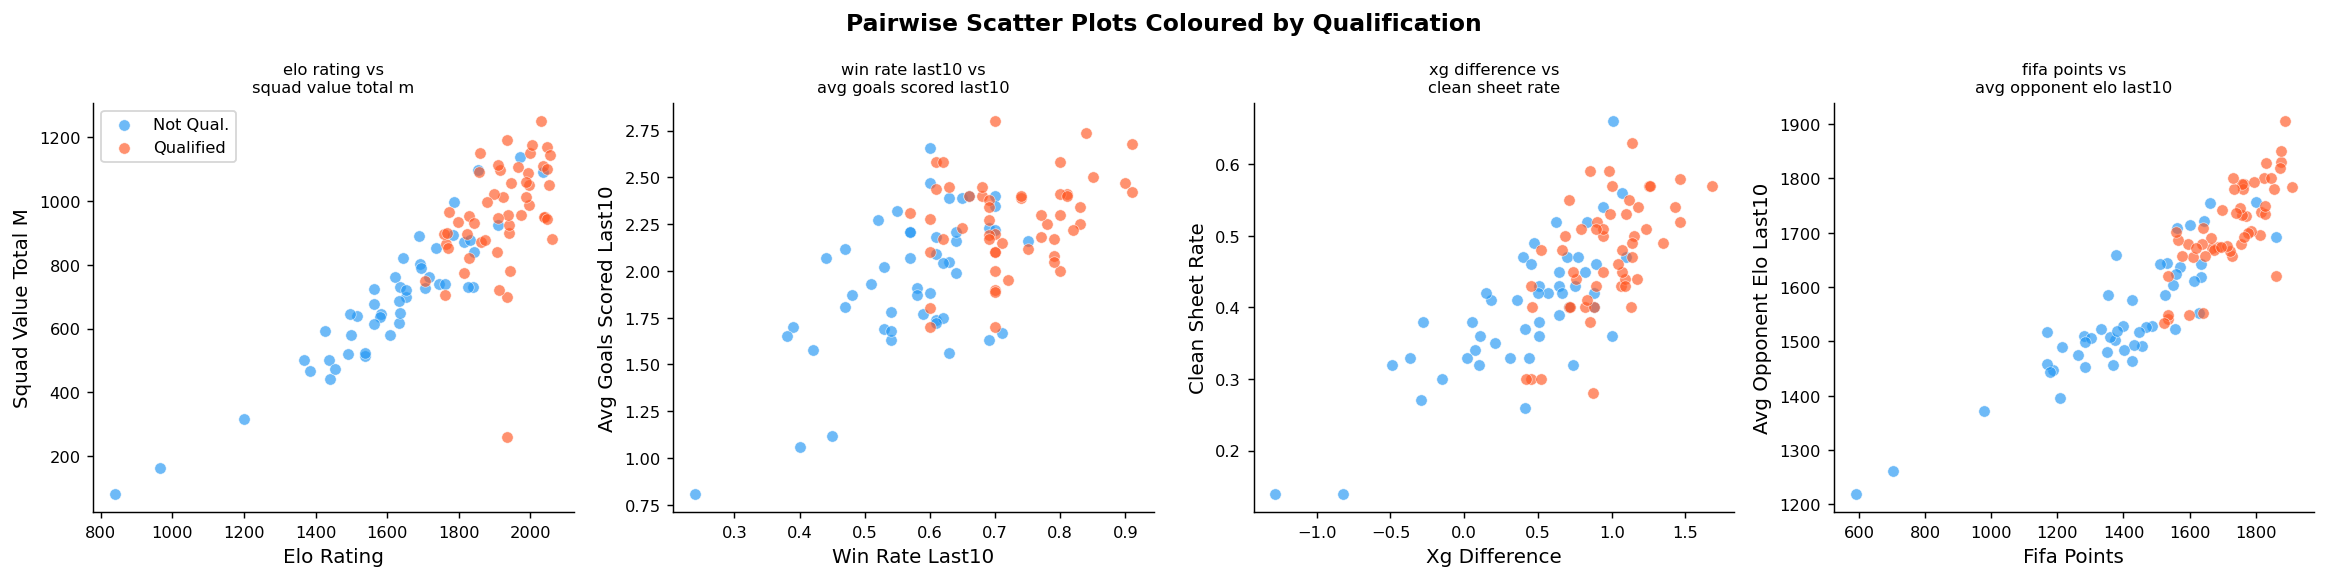

In [13]:
pairs = [
    ('elo_rating',          'squad_value_total_m'),
    ('win_rate_last10',     'avg_goals_scored_last10'),
    ('xg_difference',       'clean_sheet_rate'),
    ('fifa_points',         'avg_opponent_elo_last10'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, (xcol, ycol) in zip(axes, pairs):
    for val, color, label in zip([0, 1], PALETTE_QUAL, ['Not Qual.', 'Qualified']):
        mask = df['qualified_for_wc2026'] == val
        ax.scatter(df.loc[mask, xcol], df.loc[mask, ycol],
                   c=color, alpha=0.65, s=40, label=label, edgecolors='white', linewidth=0.4)
    ax.set_xlabel(xcol.replace('_', ' ').title())
    ax.set_ylabel(ycol.replace('_', ' ').title())
    ax.set_title(f'{xcol.replace("_"," ")} vs\n{ycol.replace("_"," ")}', fontsize=9)
    if ax == axes[0]: ax.legend()

plt.suptitle('Pairwise Scatter Plots Coloured by Qualification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6 · Correlation Analysis

### 6.1 Full correlation heatmap

Helps identify:
- **Strongly correlated feature pairs** (potential multicollinearity — can destabilise linear models and inflate feature importance in trees)
- **Features most correlated with the target**


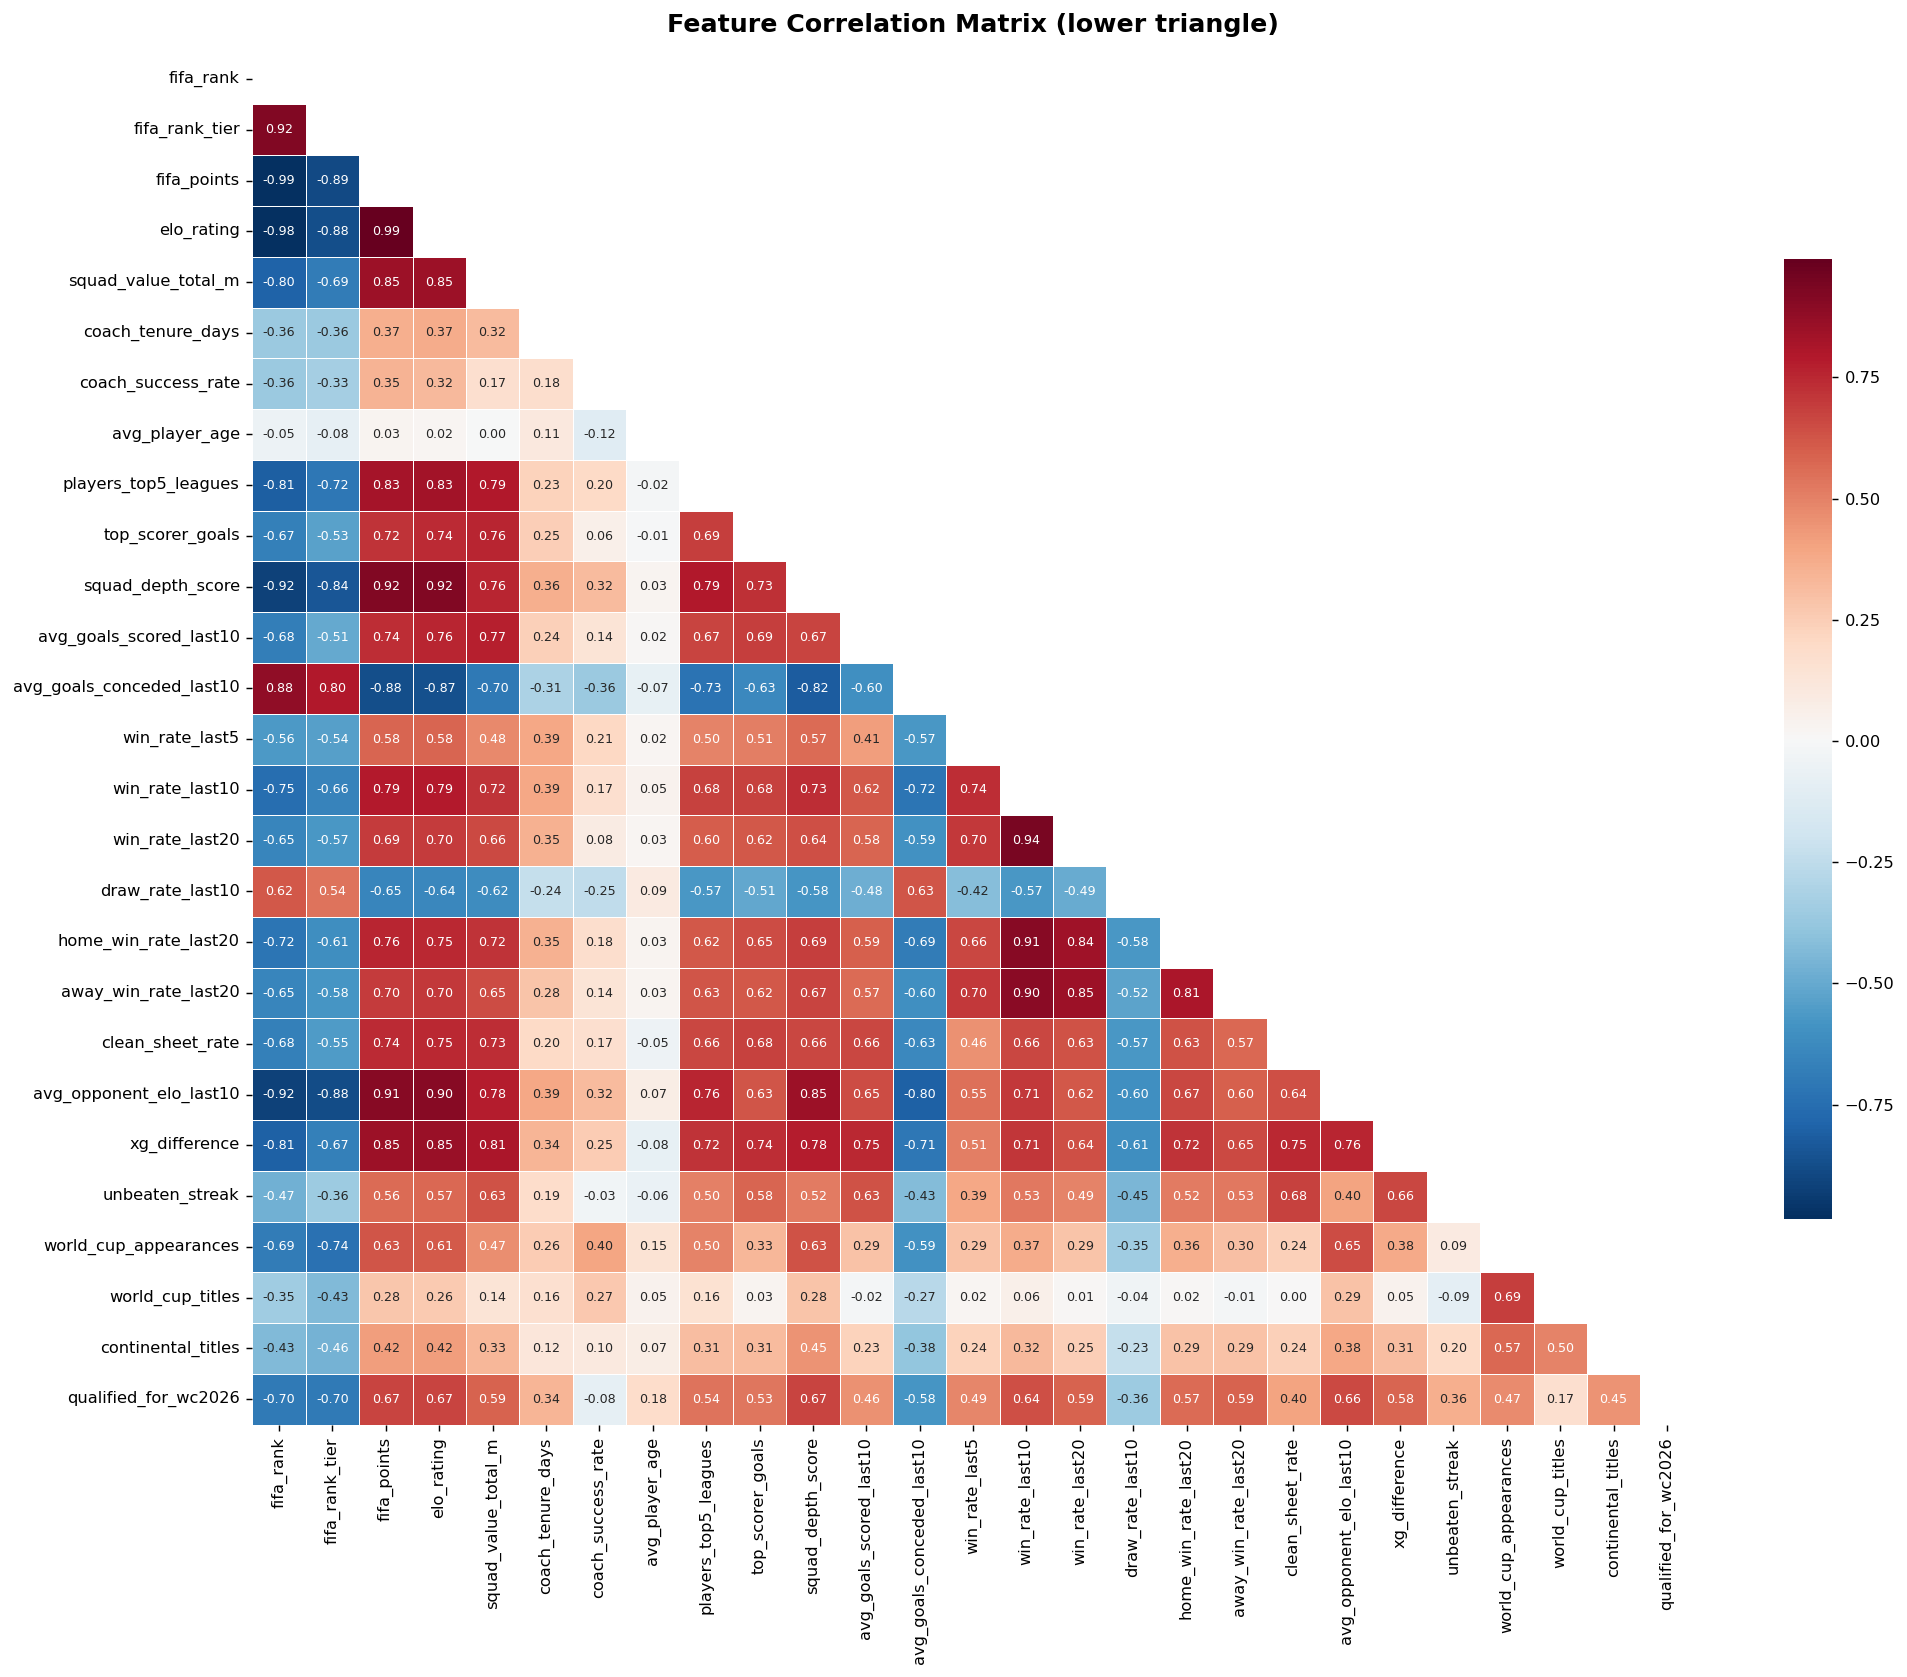

In [14]:
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, linecolor='white',
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


### 6.2 Feature — Target correlation bar chart


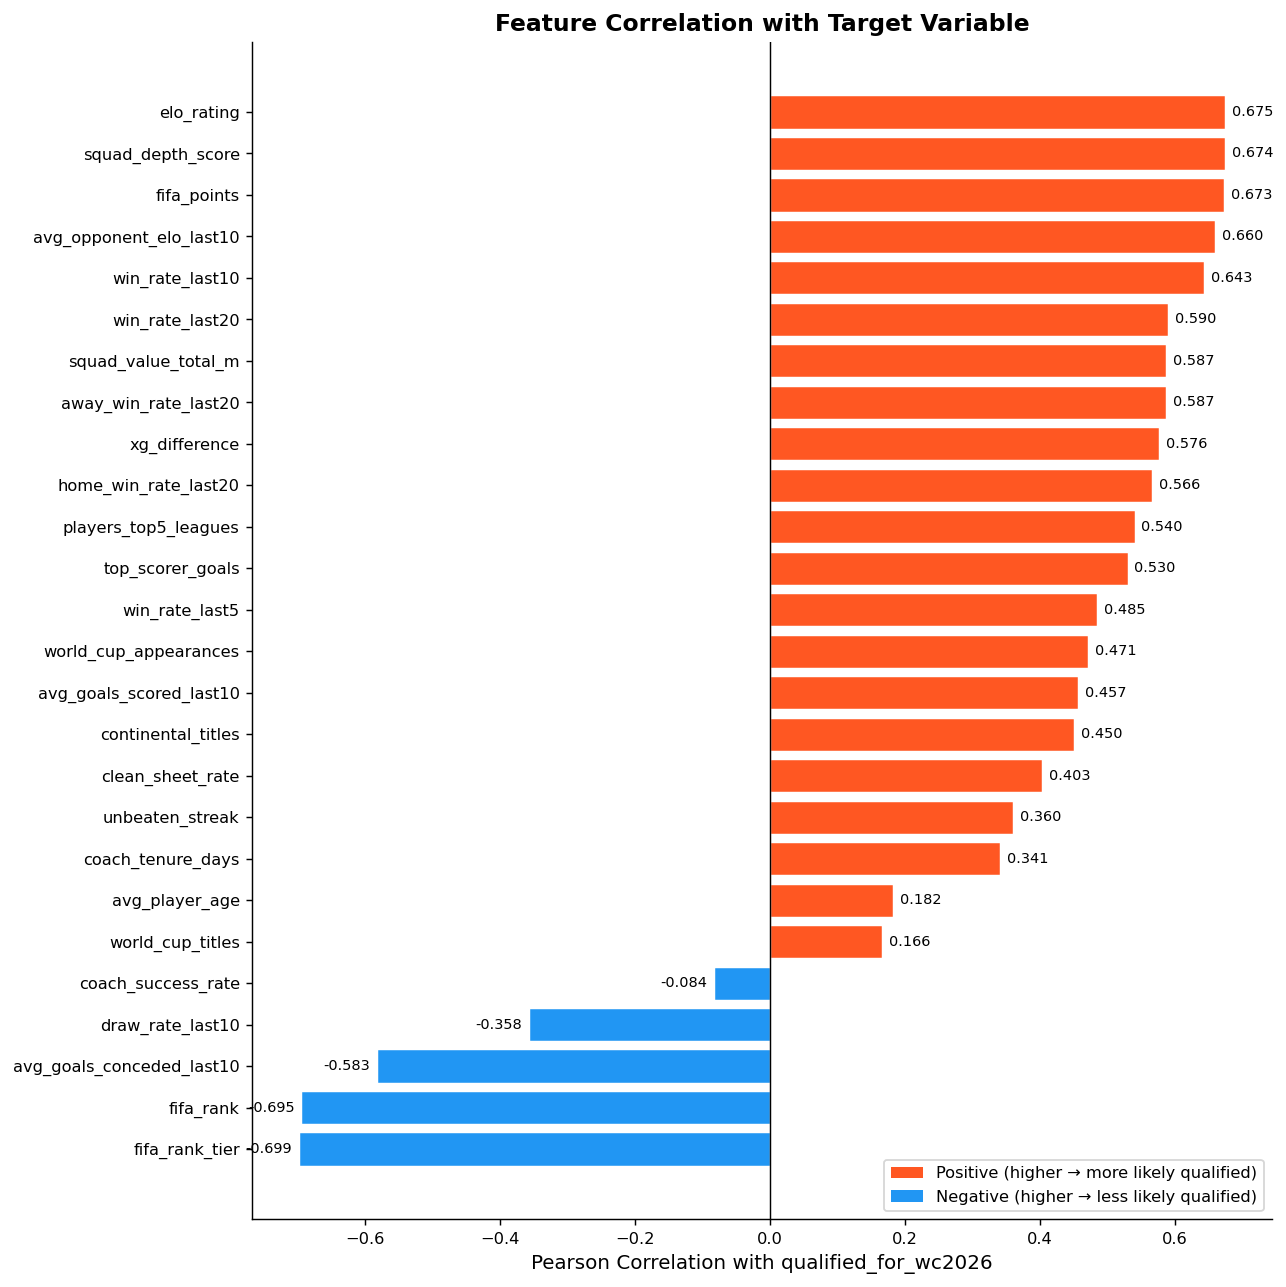

In [15]:
target_corr = (corr['qualified_for_wc2026']
               .drop('qualified_for_wc2026')
               .sort_values())

colors = ['#FF5722' if v > 0 else '#2196F3' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with qualified_for_wc2026')
ax.set_title('Feature Correlation with Target Variable', fontsize=13, fontweight='bold')

legend_elements = [Patch(facecolor='#FF5722', label='Positive (higher → more likely qualified)'),
                   Patch(facecolor='#2196F3', label='Negative (higher → less likely qualified)')]
ax.legend(handles=legend_elements, loc='lower right')

# annotate values
for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()


### 6.3 Highly correlated feature pairs (|r| > 0.85) — multicollinearity audit


In [16]:
threshold = 0.85
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = (upper.stack()
                        .reset_index()
                        .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: 'Pearson r'})
                        .query('abs(`Pearson r`) > @threshold')
                        .sort_values('Pearson r', ascending=False))

if len(high_corr_pairs) == 0:
    print("✅ No feature pairs exceed |r| = 0.85 — multicollinearity is not a major concern.")
else:
    print(f"⚠️  {len(high_corr_pairs)} highly correlated pairs found (|r| > {threshold}):")
    display(high_corr_pairs.style.format({'Pearson r': '{:.3f}'}))
    print("\n💡 Consider dropping one from each pair or using PCA before linear models.")


⚠️  22 highly correlated pairs found (|r| > 0.85):


,Feature A,Feature B,Pearson r
51,fifa_points,elo_rating,0.994
273,win_rate_last10,win_rate_last20,0.942
0,fifa_rank,fifa_rank_tier,0.923
58,fifa_points,squad_depth_score,0.921
81,elo_rating,squad_depth_score,0.917
68,fifa_points,avg_opponent_elo_last10,0.908
275,win_rate_last10,home_win_rate_last20,0.905
91,elo_rating,avg_opponent_elo_last10,0.901
276,win_rate_last10,away_win_rate_last20,0.898
11,fifa_rank,avg_goals_conceded_last10,0.882



💡 Consider dropping one from each pair or using PCA before linear models.


## 7 · Confederation Deep Dive

Different confederations have very different talent pools, competitive environments, and WC slot allocations.  
Understanding these differences helps with feature engineering (e.g. confederation-relative ranking).


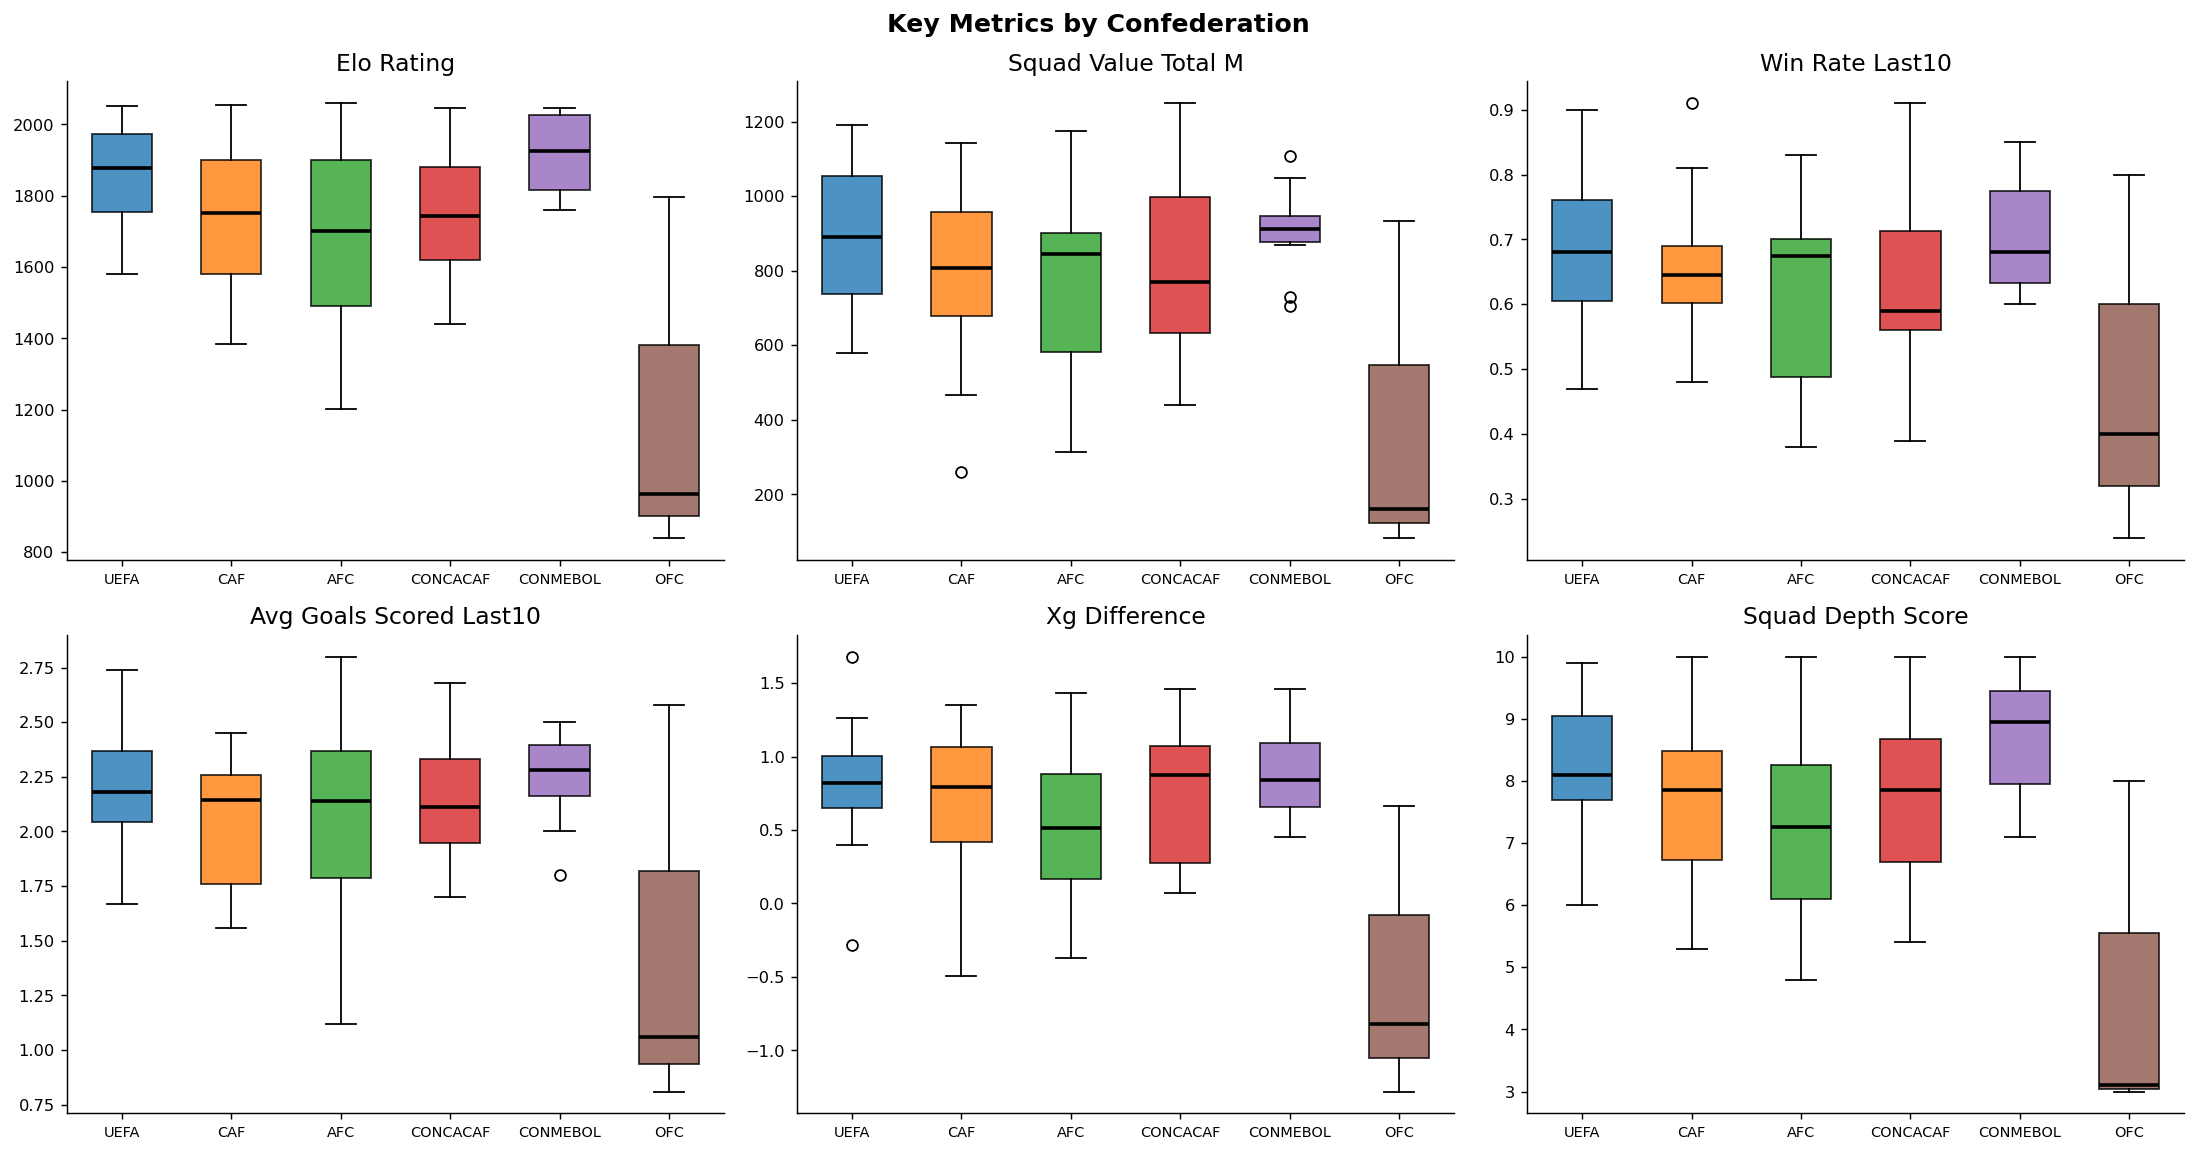

In [17]:
key_metrics = ['elo_rating', 'squad_value_total_m', 'win_rate_last10',
               'avg_goals_scored_last10', 'xg_difference', 'squad_depth_score']

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for ax, metric in zip(axes, key_metrics):
    conf_data = [df.loc[df['confederation'] == c, metric].values for c in CONF_ORDER]
    bp = ax.boxplot(conf_data, patch_artist=True, widths=0.55,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE_CONF):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    ax.set_xticklabels(CONF_ORDER, fontsize=8)
    ax.set_title(metric.replace('_', ' ').title())

plt.suptitle('Key Metrics by Confederation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


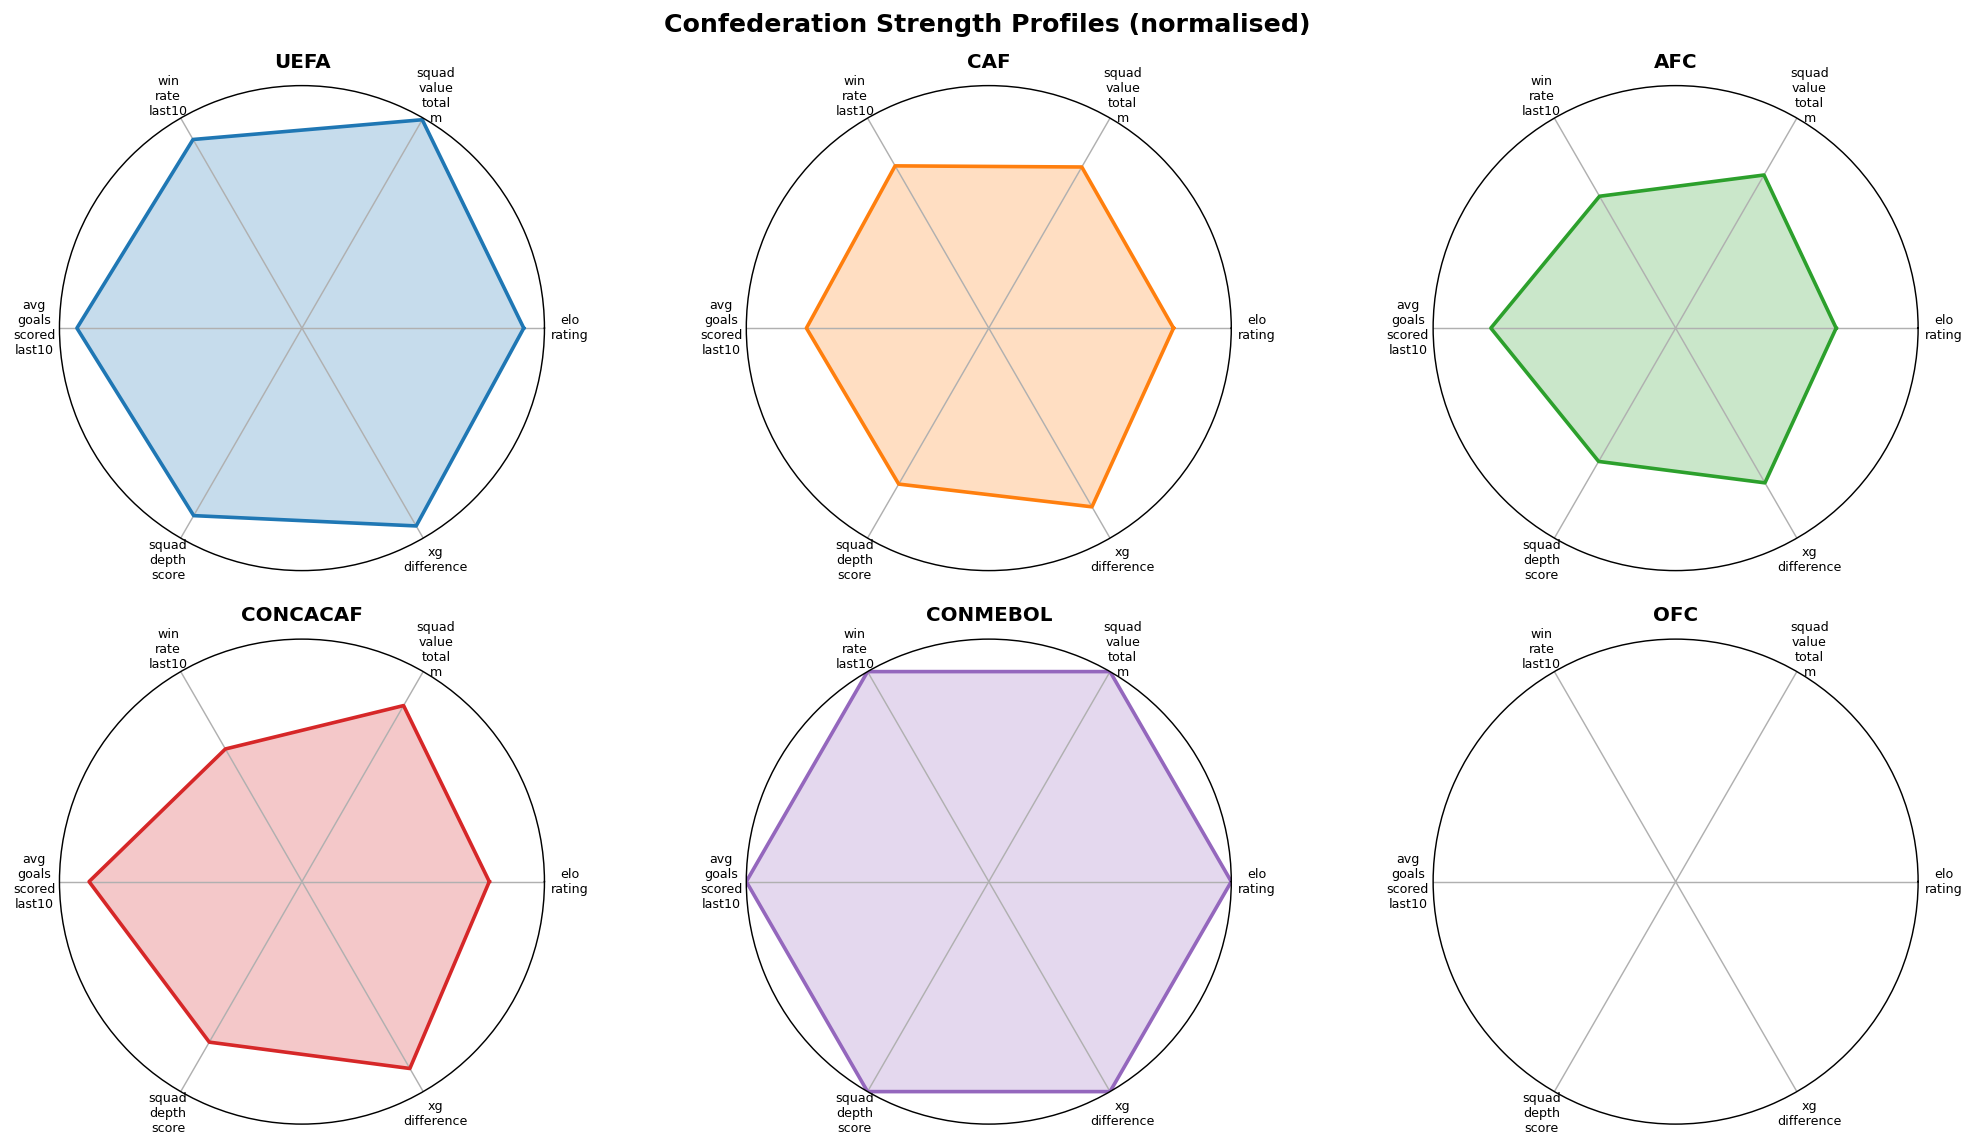

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import FancyArrowPatch

# Assuming df, CONF_ORDER, PALETTE_CONF are defined in previous cells or context

radar_features = ['elo_rating', 'squad_value_total_m', 'win_rate_last10',
                  'avg_goals_scored_last10', 'squad_depth_score', 'xg_difference']

# Normalise 0-1 for radar
radar_df = df.groupby('confederation')[radar_features].mean()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)
radar_norm = radar_norm.reindex(CONF_ORDER)

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), subplot_kw=dict(polar=True))
for ax, (conf, color) in zip(axes.flatten(), zip(CONF_ORDER, PALETTE_CONF)):
    vals = radar_norm.loc[conf].tolist() + radar_norm.loc[conf].tolist()[:1]
    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f.replace('_', '\n') for f in radar_features], fontsize=7)
    ax.set_yticks([]); ax.set_title(conf, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylim(0, 1)

plt.suptitle('Confederation Strength Profiles (normalised)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8 · Outlier Detection

We use the **IQR fence** (1.5 × IQR) and **Z-score** (|z| > 3) methods.  
Outliers are not necessarily errors — a team with 22 WC appearances is a genuine data point, not noise.  
The goal here is to *identify* them so we handle them deliberately in preprocessing.


In [20]:
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

def zscore_outliers(series):
    return (np.abs(stats.zscore(series)) > 3).sum()

out_summary = pd.DataFrame({
    'IQR outliers'    : {c: iqr_outliers(df[c])    for c in NUMERIC_COLS},
    'ZScore outliers' : {c: zscore_outliers(df[c]) for c in NUMERIC_COLS},
})
out_summary['max_outliers'] = out_summary.max(axis=1)
out_summary = out_summary.sort_values('max_outliers', ascending=False)
out_summary[out_summary['max_outliers'] > 0].style.background_gradient(cmap='YlOrRd')


,IQR outliers,ZScore outliers,max_outliers
world_cup_titles,9,4,9
win_rate_last10,8,1,8
coach_tenure_days,8,2,8
continental_titles,6,3,6
world_cup_appearances,6,1,6
avg_player_age,5,0,5
win_rate_last5,4,0,4
xg_difference,3,2,3
avg_goals_scored_last10,3,2,3
away_win_rate_last20,2,1,2


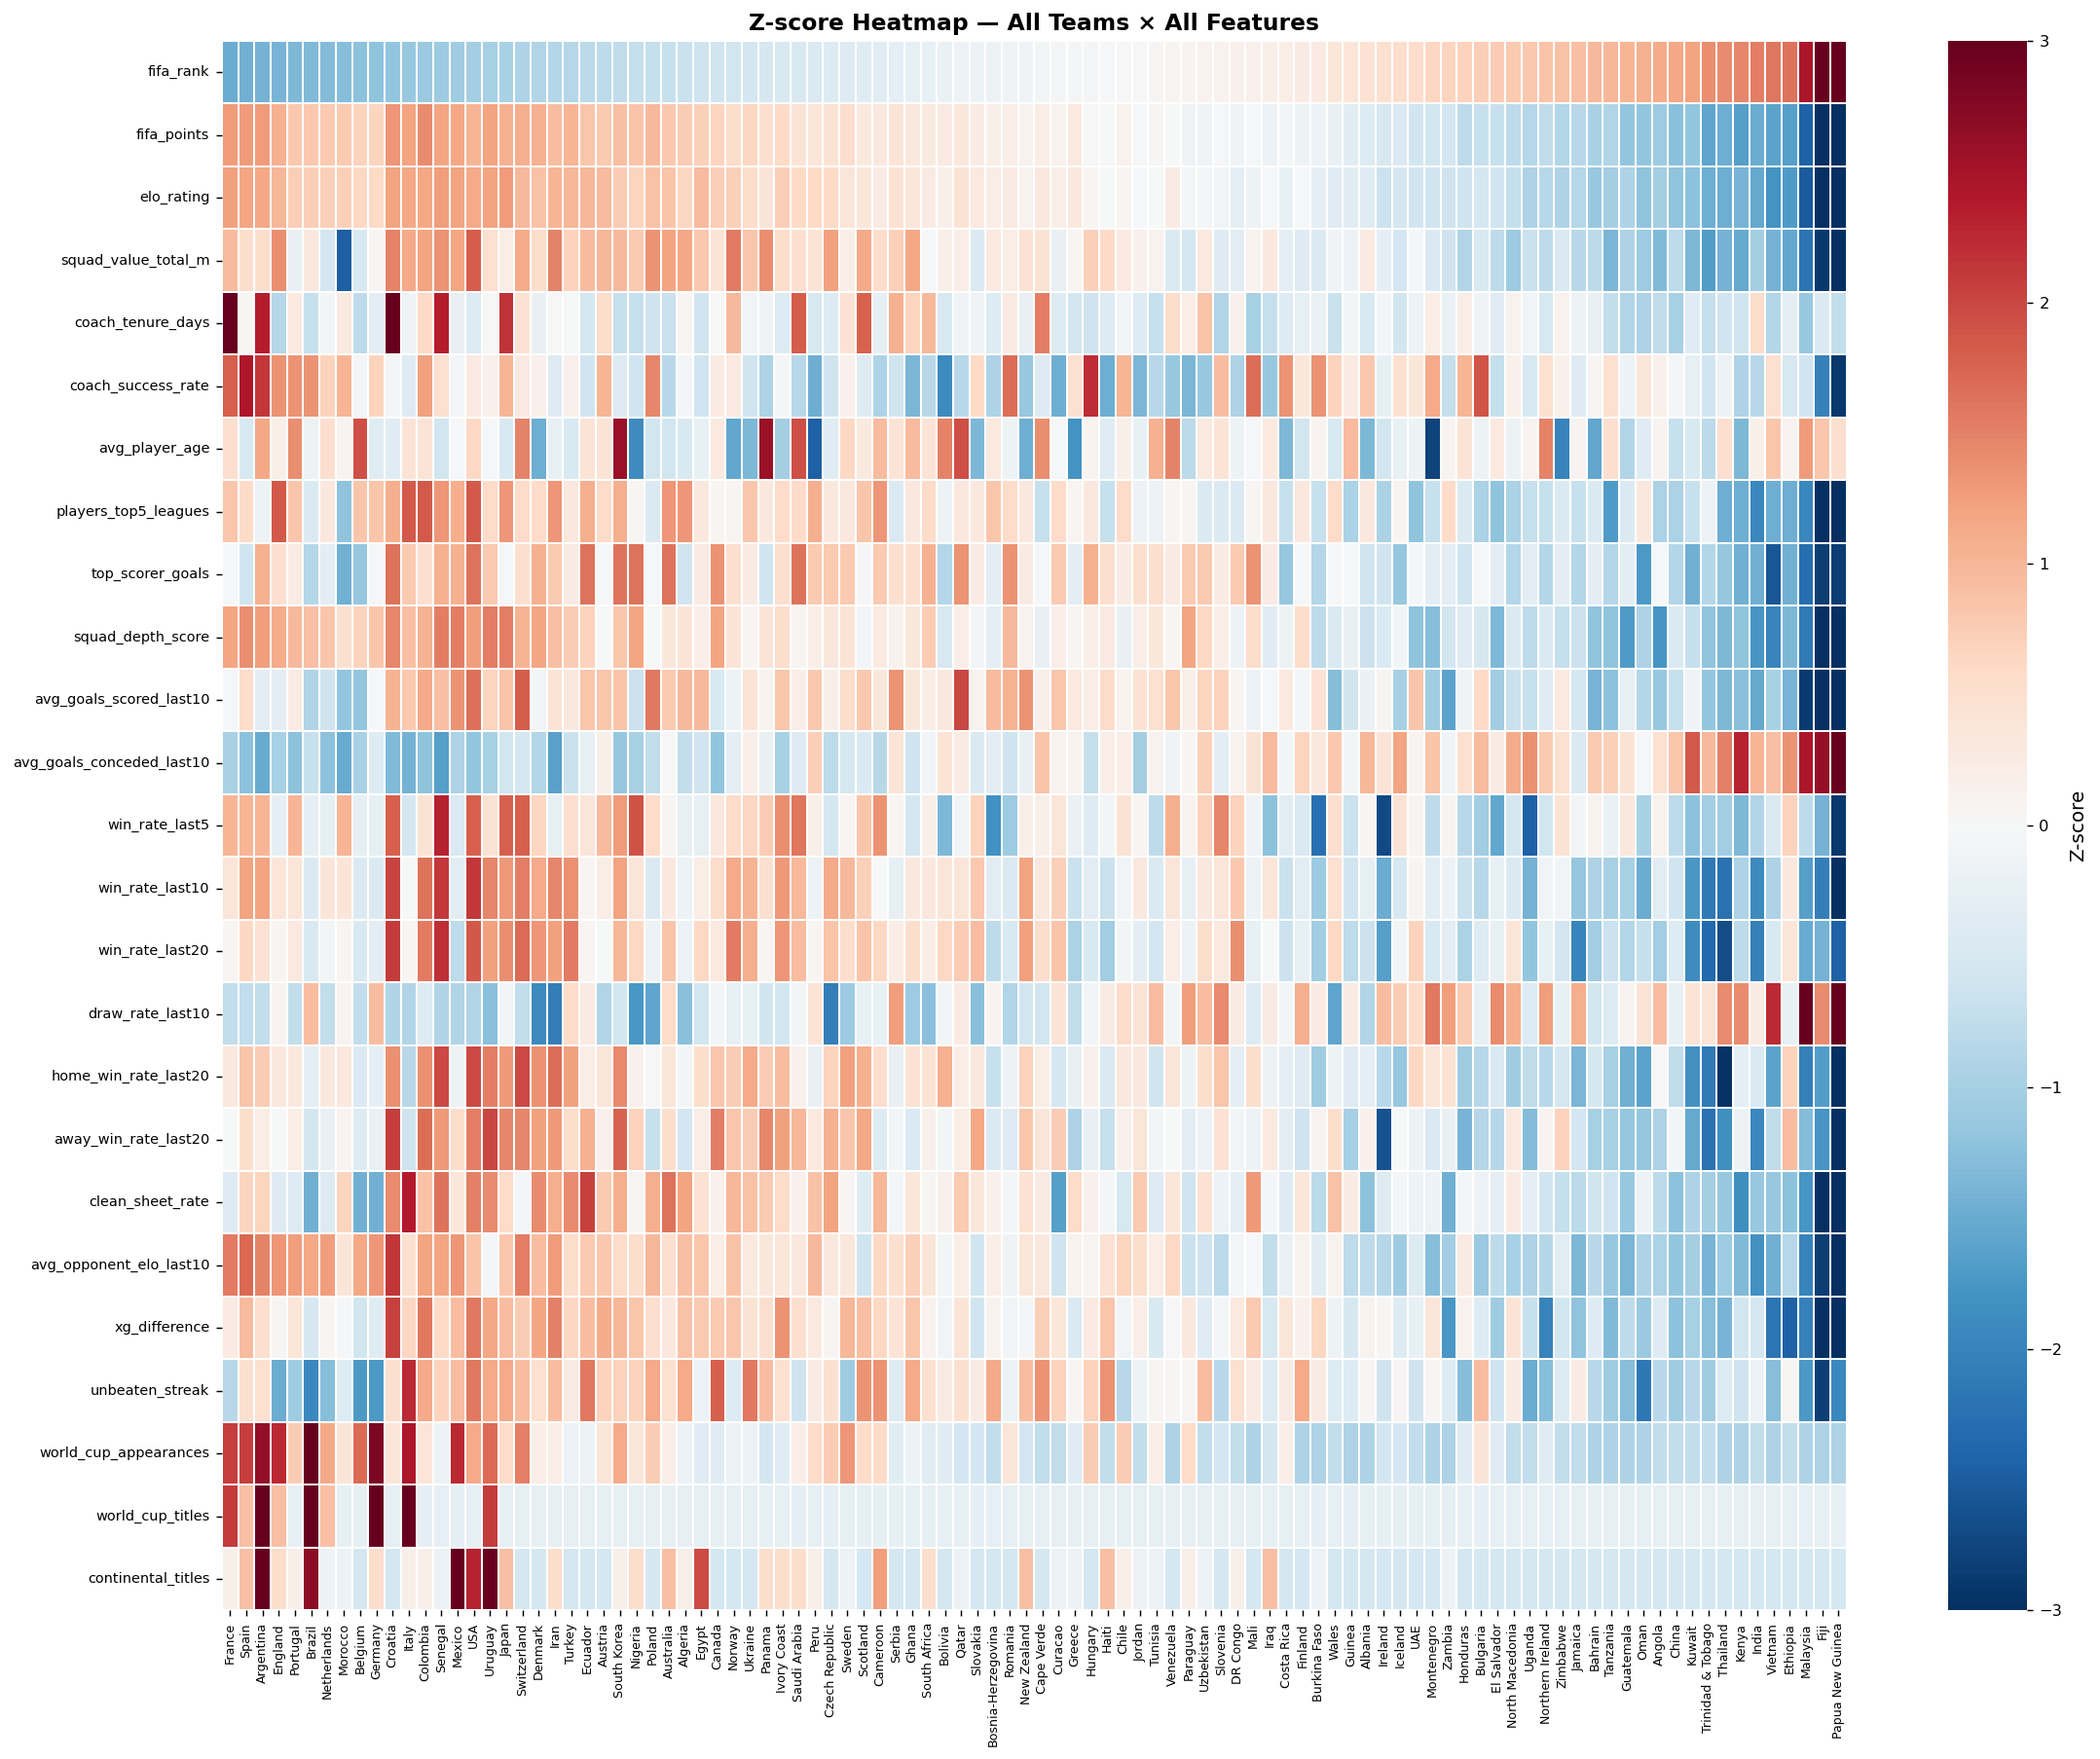

Cells > |3| (red/blue extremes) are flagged outliers.


In [21]:
# ── Z-score heatmap ——————————————————————————————————————————————————————
z_df = df[NUMERIC_COLS].apply(stats.zscore)

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(z_df.T, cmap='RdBu_r', center=0, vmin=-3, vmax=3,
            xticklabels=df['country'], yticklabels=NUMERIC_COLS,
            linewidths=0.2, ax=ax, cbar_kws={'label': 'Z-score'})
ax.set_title('Z-score Heatmap — All Teams × All Features', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.show()
print("Cells > |3| (red/blue extremes) are flagged outliers.")


## 9 · Key Findings & Feature Engineering Hypotheses

### 9.1 Dataset quality


In [22]:
summary_points = [
    ("✅ No missing values",             "Clean data; no imputation required."),
    ("⚖️  Near-balanced target",         "52% qualified / 48% not — no aggressive resampling needed."),
    ("📊 100 teams, 28 features",         "Compact dataset; risk of overfitting warrants regularisation."),
    ("🔢 Mixed dtypes",                  "Mostly float64/int64; two object cols (country, coach) for ID only."),
]

for icon_title, detail in summary_points:
    print(f"  {icon_title:<35} → {detail}")


  ✅ No missing values                 → Clean data; no imputation required.
  ⚖️  Near-balanced target            → 52% qualified / 48% not — no aggressive resampling needed.
  📊 100 teams, 28 features            → Compact dataset; risk of overfitting warrants regularisation.
  🔢 Mixed dtypes                      → Mostly float64/int64; two object cols (country, coach) for ID only.


### 9.2 Most predictive features (per correlation + Mann-Whitney)


In [23]:
print("TOP POSITIVE PREDICTORS (higher value → more likely qualified)")
print("─" * 60)
positive = mw_df[mw_df['delta_pct'] > 0].head(8)
for _, row in positive.iterrows():
    print(f"  {row['feature']:<35} Δmedian={row['delta_pct']:+.1f}%  p={row['mw_p_value']:.4f} {row['significant']}")

print()
print("TOP NEGATIVE PREDICTORS (lower value → more likely qualified)")
print("─" * 60)
negative = mw_df[mw_df['delta_pct'] < 0].head(4)
for _, row in negative.iterrows():
    print(f"  {row['feature']:<35} Δmedian={row['delta_pct']:+.1f}%  p={row['mw_p_value']:.4f} {row['significant']}")


TOP POSITIVE PREDICTORS (higher value → more likely qualified)
────────────────────────────────────────────────────────────
  elo_rating                          Δmedian=+18.4%  p=0.0000 ✅
  fifa_points                         Δmedian=+22.9%  p=0.0000 ✅
  squad_depth_score                   Δmedian=+24.1%  p=0.0000 ✅
  avg_opponent_elo_last10             Δmedian=+11.8%  p=0.0000 ✅
  win_rate_last10                     Δmedian=+17.6%  p=0.0000 ✅
  squad_value_total_m                 Δmedian=+34.7%  p=0.0000 ✅
  xg_difference                       Δmedian=+90.1%  p=0.0000 ✅
  continental_titles                  Δmedian=+200000000000.0%  p=0.0000 ✅

TOP NEGATIVE PREDICTORS (lower value → more likely qualified)
────────────────────────────────────────────────────────────
  fifa_rank                           Δmedian=-62.1%  p=0.0000 ✅
  avg_goals_conceded_last10           Δmedian=-28.2%  p=0.0000 ✅
  draw_rate_last10                    Δmedian=-30.3%  p=0.0007 ✅
  coach_success_rate       

### 9.3 Feature engineering hypotheses

Based on the EDA above, here are concrete ideas to implement in `02_feature_engineering.ipynb`:


In [24]:
hypotheses = {
    "Composite Strength Index"       : "Weighted combination of elo_rating, squad_value, win_rate_last10 → single 'team strength' score.",
    "Rank Ratio (relative)"          : "fifa_rank / confederation_avg_rank → how good a team is *within* their confederation.",
    "Attack/Defence Balance"         : "avg_goals_scored_last10 / avg_goals_conceded_last10 → goal ratio proxy for dominance.",
    "Experience Score"               : "world_cup_appearances × (1 + world_cup_titles) → non-linear WC pedigree.",
    "Form Trajectory"                : "win_rate_last5 - win_rate_last20 → improving or declining momentum.",
    "Squad Value per Player"         : "squad_value_total_m / players_top5_leagues → quality concentration metric.",
    "Competitive Opponent ELO"       : "avg_opponent_elo_last10 × win_rate_last10 → results against *quality* opposition.",
    "Clean Sheet Interaction"        : "clean_sheet_rate × squad_depth_score → deep & defensively sound teams.",
    "Coach Efficiency"               : "coach_success_rate × log1p(coach_tenure_days) → sustained winning culture.",
    "Home/Away Split Diff"           : "home_win_rate_last20 - away_win_rate_last20 → travel/pressure robustness.",
}

print("Feature Engineering Hypotheses for 02_feature_engineering.ipynb")
print("=" * 65)
for feat, rationale in hypotheses.items():
    print(f"\n  📌 {feat}")
    print(f"     {rationale}")


Feature Engineering Hypotheses for 02_feature_engineering.ipynb

  📌 Composite Strength Index
     Weighted combination of elo_rating, squad_value, win_rate_last10 → single 'team strength' score.

  📌 Rank Ratio (relative)
     fifa_rank / confederation_avg_rank → how good a team is *within* their confederation.

  📌 Attack/Defence Balance
     avg_goals_scored_last10 / avg_goals_conceded_last10 → goal ratio proxy for dominance.

  📌 Experience Score
     world_cup_appearances × (1 + world_cup_titles) → non-linear WC pedigree.

  📌 Form Trajectory
     win_rate_last5 - win_rate_last20 → improving or declining momentum.

  📌 Squad Value per Player
     squad_value_total_m / players_top5_leagues → quality concentration metric.

  📌 Competitive Opponent ELO
     avg_opponent_elo_last10 × win_rate_last10 → results against *quality* opposition.

  📌 Clean Sheet Interaction
     clean_sheet_rate × squad_depth_score → deep & defensively sound teams.

  📌 Coach Efficiency
     coach_success_ra

### 9.4 Modelling recommendations


In [25]:
recs = [
    ("Baseline", "Logistic Regression with L2 (interpretable; linear boundaries may suffice given strong correlations)"),
    ("Tree ensemble", "Random Forest / XGBoost — handles non-linearities, robust to scale differences"),
    ("Feature selection", "Drop highly correlated duplicates (e.g. fifa_rank + fifa_rank_tier), use Boruta or SHAP for selection"),
    ("Validation", "Stratified K-Fold (k=5) given small N=100; keep confederation as a stratification hint"),
    ("Eval metrics", "ROC-AUC + F1-score; avoid accuracy alone due to class near-balance masking recall"),
    ("Explainability", "SHAP values on final model — important for a football analytics narrative"),
]

print("Modelling Recommendations → 03_modelling.ipynb")
print("=" * 60)
for step, rec in recs:
    print(f"  [{step:<20}] {rec}")


Modelling Recommendations → 03_modelling.ipynb
  [Baseline            ] Logistic Regression with L2 (interpretable; linear boundaries may suffice given strong correlations)
  [Tree ensemble       ] Random Forest / XGBoost — handles non-linearities, robust to scale differences
  [Feature selection   ] Drop highly correlated duplicates (e.g. fifa_rank + fifa_rank_tier), use Boruta or SHAP for selection
  [Validation          ] Stratified K-Fold (k=5) given small N=100; keep confederation as a stratification hint
  [Eval metrics        ] ROC-AUC + F1-score; avoid accuracy alone due to class near-balance masking recall
  [Explainability      ] SHAP values on final model — important for a football analytics narrative


---
## ✅ EDA Complete

**Next notebook:** `02_feature_engineering.ipynb`

*This notebook was generated as part of the FIFA World Cup 2026 Analytics & Prediction Pipeline.*
